In [87]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor




In [88]:
# Raw data


# Clinical Data
df = pl.read_csv("../data/raw/X_train/clinical_train.csv")
df_eval = pl.read_csv("../data/raw/X_test/clinical_test.csv")

# Molecular Data
mol_df = pl.read_csv("../data/raw/X_train/molecular_train.csv")
mol_eval = pl.read_csv("../data/raw/X_test/molecular_test.csv" , ignore_errors=True)


target_df = pl.read_csv("../data/raw/target_train.csv")


In [89]:
# Clinical Data
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,109,272,193,601,110,124,387


In [90]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,str,f64,f64,f64,f64,f64,f64,str
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936"""
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387"""
"""mean""",null,null,5.982545,6.535164,3.264735,0.955868,9.893549,167.0489,null
"""std""",null,null,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,null
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.0,2.0,"""+8(fish)"""
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null
"""max""","""P132729""","""VU""",91.0,154.4,109.62,44.2,16.6,1451.0,"""tris8"""


In [91]:
quant_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
sub_df = df.select(quant_vars)

# Conver to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
df = df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [92]:
mol_df.null_count()

ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,114,114,114,114,114,0,12,0,89,114


In [93]:
mol_df.describe()

statistic,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
str,str,str,f64,f64,str,str,str,str,str,f64,f64
"""count""","""10935""","""10821""",10821.0,10821.0,"""10821""","""10821""","""10935""","""10923""","""10935""",10846.0,10821.0
"""null_count""","""0""","""114""",114.0,114.0,"""114""","""114""","""0""","""12""","""0""",89.0,114.0
"""mean""",null,null,8.0783e7,8.0783e7,null,null,null,null,null,0.305087,1051.229554
"""std""",null,null,5.6427e7,5.6427e7,null,null,null,null,null,0.211524,552.861902
"""min""","""P100000""","""1""",394899.0,394899.0,"""A""","""A""","""ABL1""","""FLT3_ITD""","""2KB_upstream_variant""",0.02,16.0
"""25%""",null,null,3.1022441e7,3.1022442e7,null,null,null,null,null,0.1025,660.0
"""50%""",null,null,7.4732959e7,7.4732959e7,null,null,null,null,null,0.3213,975.0
"""75%""",null,null,1.15258747e8,1.15258747e8,null,null,null,null,null,0.442,1353.0
"""max""","""P132729""","""X""",2.26252135e8,2.26252135e8,"""TTTTCA""","""TTTTC""","""ZRSR2""","""p.Y974fs*8""","""synonymous_codon""",0.999,7156.0


In [94]:
quant_vars = ["VAF" , "DEPTH"]
sub_df = mol_df.select(quant_vars)

# Conver to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
mol_df = mol_df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [95]:
target_df = target_df.fill_null(strategy="forward")

# OUTLIERS TREATEMENT

# Method IQR 

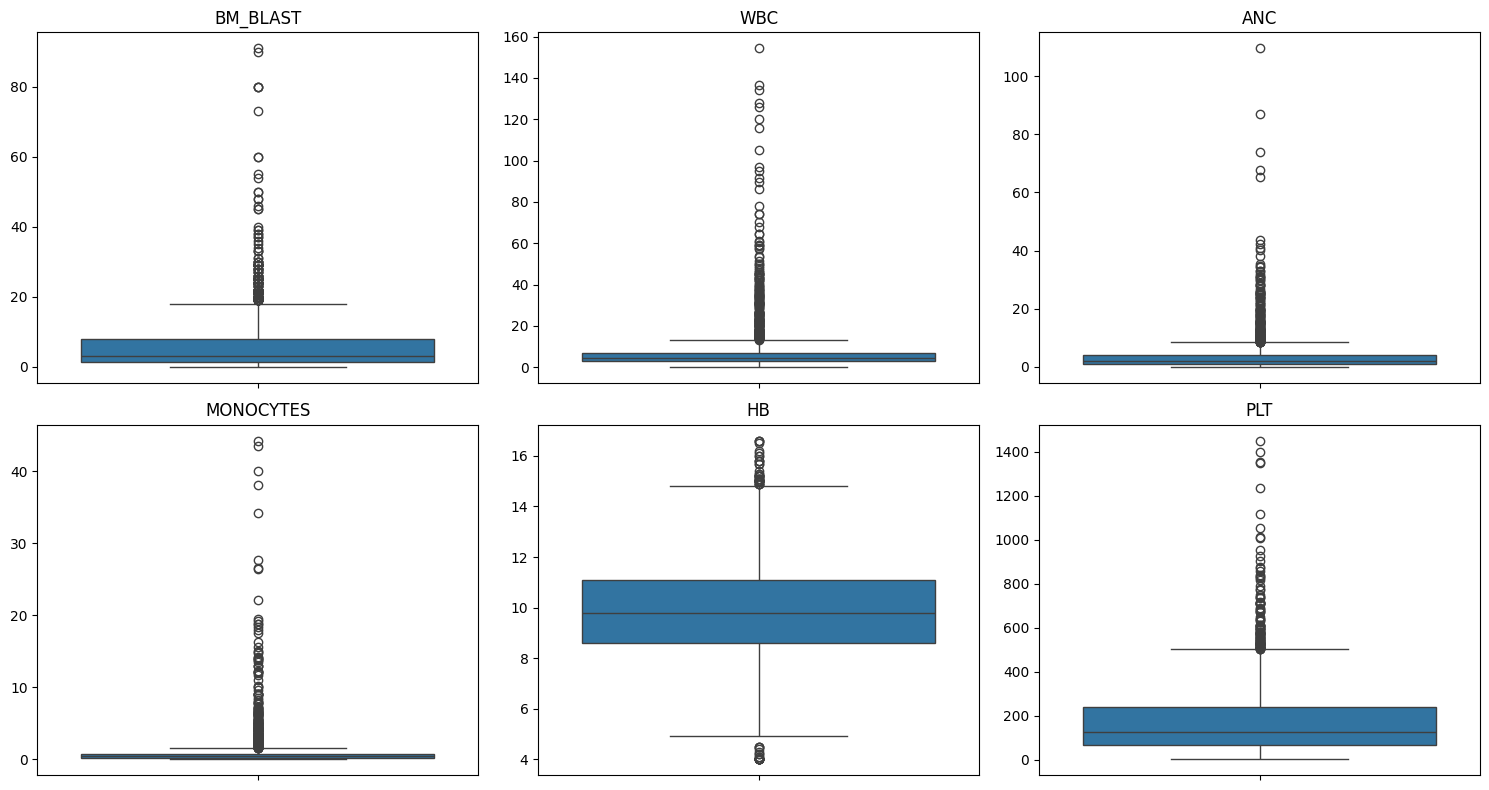

In [96]:
cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3

plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    
    plt.subplot(row,col,index + 1)
    plt.title(cl)
    sns.boxplot(df[cl])

plt.tight_layout()
plt.show()  

In [ ]:
# Clinical Data

cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3


plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    q1 = df.select(pl.col(cl).quantile(0.25)).item()
    q3 = df.select(pl.col(cl).quantile(0.75)).item()
    
    iqr = q3 - q1
    
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df.filter(
        (pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound)
    )
    



    # Winsorisation : caper les valeurs extrêmes
    df = df.with_columns(
        pl.when(pl.col(cl) < lower_bound).then(lower_bound)
        .when(pl.col(cl) > upper_bound).then(upper_bound)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    
    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")


Number of outliers in column : BM_BLAST is : 181
Number of outliers in column : WBC is : 212
Number of outliers in column : ANC is : 189
Number of outliers in column : MONOCYTES is : 337
Number of outliers in column : HB is : 58
Number of outliers in column : PLT is : 110


<Figure size 1500x800 with 0 Axes>

In [98]:


cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

for cl in cl_quantitative_var:
    mean = df.select(pl.col(cl).mean()).item()
    std = df.select(pl.col(cl).std()).item()

    z_scores = df.select(((pl.col(cl) - mean) / std).alias("z"))

    # On ajoute les Z-scores temporairement au DataFrame
    df_with_z = df.with_columns(((pl.col(cl) - mean) / std).alias(f"z_{cl}"))

    # Filtrer les outliers : abs(Z) > 3
    outliers = df_with_z.filter(pl.col(f"z_{cl}").abs() > 3)
    
    
    # Median
    median_val = df.select(pl.col(cl).median()).item()

    df = df.with_columns(
        pl.when((pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound))
        .then(median_val)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    # # Winsorisation : caper les valeurs extrêmes
    # df = df.with_columns(
    #     pl.when(pl.col(cl) < lower_bound).then(lower_bound)
    #     .when(pl.col(cl) > upper_bound).then(upper_bound)
    #     .otherwise(pl.col(cl))
    #     .alias(cl)
    # )

    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")

Number of outliers in column : BM_BLAST is : 32
Number of outliers in column : WBC is : 27
Number of outliers in column : ANC is : 36
Number of outliers in column : MONOCYTES is : 44
Number of outliers in column : HB is : 0
Number of outliers in column : PLT is : 14
